# Kink positions in the continuum paper's companions figure: measurement from the vector PDF

Source: `D:\MPIA\arXiv-2504.18725v1\Figures\comparison_companions.pdf`, the original vector figure from the arXiv source of the exoALMA continuum paper (arXiv:2504.18725, Figure "comparison_companions", label `fig:companions`). It compares the continuum with the $^{12}$CO velocity kinks of Pinte et al. 2025.

The figure has 6 rows (disks) and 3 columns:
- left: fiducial CLEAN image, with the kink drawn as a green circle;
- middle: frank residuals (SNR), with the same green circle;
- right: radial intensity profile, with the kink's deprojected radius $R_\mathrm{cand}$ as a green dotted line and its uncertainty as a green band.

Per the caption, circle size and band width are the gas-beam uncertainty from Pinte et al. 2025.

Unlike Figure 5 of Pinte et al. 2025 (`verify_figure5_blue_dot.ipynb`), these panels have labelled axes, so arcsec come straight from the tick marks and no scale bar is needed. The 2D images are embedded rasters, but the axes, ticks, circles, $R_\mathrm{cand}$ lines and bands are all vectors.

Coordinates are native PDF points. PyMuPDF puts the origin at the top left, with x to the right and y downward.

Run the notebook one cell at a time and check each output before going on.

## Cell 1: open the PDF

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pymupdf as fitz

SRC = r'D:\MPIA\arXiv-2504.18725v1'
PDF = SRC + r'\Figures\comparison_companions.pdf'
DPI = 300
GREEN = (0, 0.5, 0)
# source distances (pc), Table 1 of the paper (Gaia DR3) -- AA Tau is 135 pc here, not the 145 in Dictionaries.disk_arr
dist_pc = {'AA_Tau': 135, 'HD_143006': 167, 'J1615': 156, 'J1842': 151, 'LkCa_15': 156, 'SY_Cha': 182}

doc = fitz.open(PDF)
page = doc[0]
dr = page.get_drawings()
print('file             :', PDF)
print('pages in file    :', len(doc))
print('page.rect        :', page.rect, f'({page.rect.width:.3f} x {page.rect.height:.3f} pt)')
print('mediabox/cropbox :', page.mediabox, page.cropbox, ' rotation:', page.rotation)
print('vector paths     :', len(dr), '  embedded images:', len(page.get_image_info()))

file             : D:\MPIA\arXiv-2504.18725v1\Figures\comparison_companions.pdf
pages in file    : 1
page.rect        : Rect(0.0, 0.0, 1652.4771728515625, 2041.6407470703125) (1652.477 x 2041.641 pt)
mediabox/cropbox : Rect(0.0, 0.0, 1652.4771728515625, 2041.6407470703125) Rect(0.0, 0.0, 1652.4771728515625, 2041.6407470703125)  rotation: 0
vector paths     : 2762   embedded images: 18


## Cell 2: render the page

rendered size (px): 6886 8507


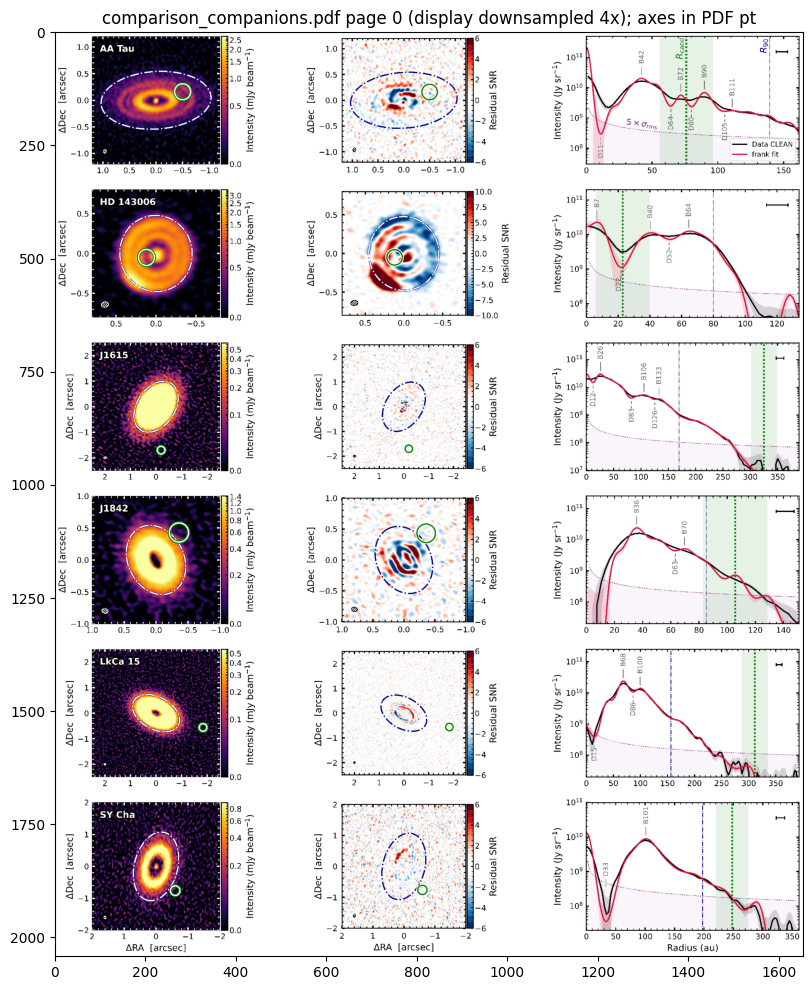

In [19]:
pix = page.get_pixmap(dpi=DPI)
print('rendered size (px):', pix.width, pix.height)
full = np.frombuffer(pix.samples, np.uint8).reshape(pix.height, pix.width, pix.n)
plt.figure(figsize=(10, 12))
plt.imshow(full[::4, ::4], extent=(page.rect.x0, page.rect.x1, page.rect.y1, page.rect.y0))
plt.title('comparison_companions.pdf page 0 (display downsampled 4x); axes in PDF pt')
plt.show()

# used for all later crops: render a clip, drawn with extent in PDF pt
def show(ax, r, dpi=DPI):
    p = page.get_pixmap(clip=r, dpi=dpi)
    s = 72 / dpi
    ax.imshow(np.frombuffer(p.samples, np.uint8).reshape(p.height, p.width, p.n),
              extent=(p.x * s, (p.x + p.width) * s, (p.y + p.height) * s, p.y * s))
    return p

## Cell 3: find the 18 axes

Each axes has four black spine segments longer than 200 pt. Top and bottom spines share the same (x0, x1), so sorted by y they alternate top, bottom.

The disk labels ("AA Tau", ...) are outlined glyphs, not text, so the rows are named by order, top to bottom. Check the names against the crops.

long black spine segments: 72 (36 horizontal)
axes rectangles found: 18
AA_Tau     clean: (81.84, 9.44, 364.01, 291.61)  resid: (634.00, 13.83, 907.38, 287.22)  profile: (1173.94, 9.44, 1643.88, 291.61)
HD_143006  clean: (81.84, 348.04, 364.01, 630.21)  resid: (634.00, 352.44, 907.38, 625.82)  profile: (1173.94, 348.04, 1643.88, 630.21)
J1615      clean: (81.84, 686.65, 364.01, 968.82)  resid: (634.00, 691.04, 907.38, 964.42)  profile: (1173.94, 686.65, 1643.88, 968.82)
J1842      clean: (81.84, 1025.25, 364.01, 1307.42)  resid: (634.00, 1029.65, 907.38, 1303.03)  profile: (1173.94, 1025.25, 1643.88, 1307.42)
LkCa_15    clean: (81.84, 1363.85, 364.01, 1646.02)  resid: (634.00, 1368.25, 907.38, 1641.63)  profile: (1173.94, 1363.85, 1643.88, 1646.02)
SY_Cha     clean: (81.84, 1702.46, 364.01, 1984.63)  resid: (634.00, 1706.85, 907.38, 1980.23)  profile: (1173.94, 1702.46, 1643.88, 1984.63)


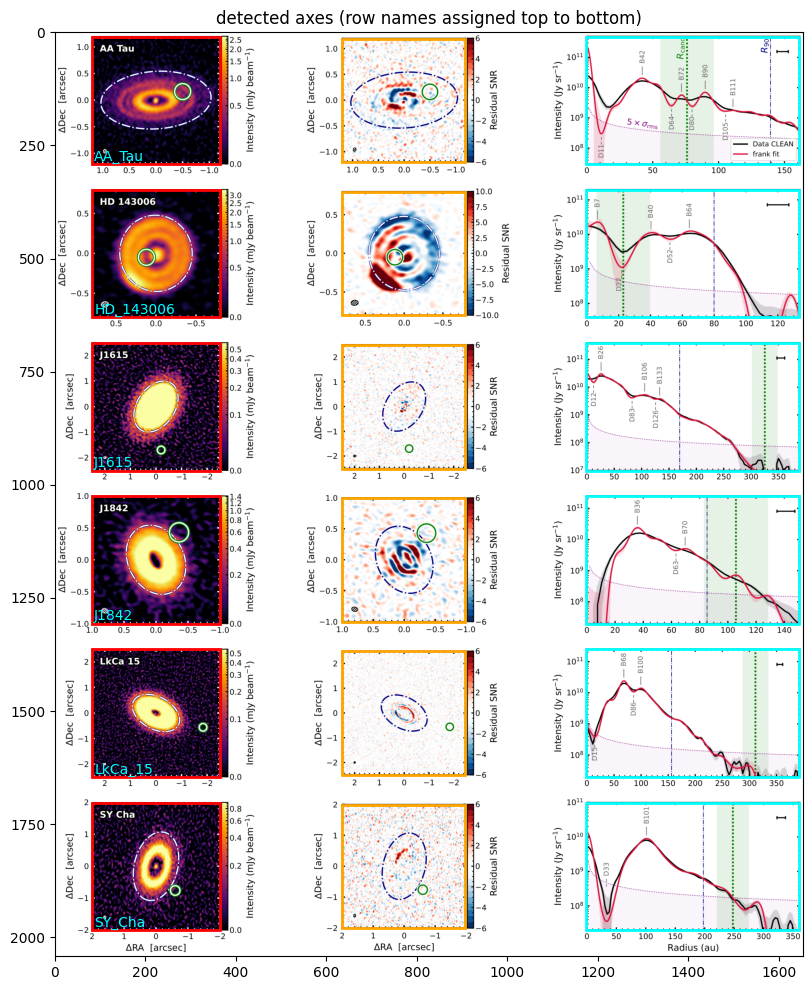

In [20]:
lines = [d['rect'] for d in dr if d['type'] == 's' and d['color'] == (0, 0, 0) and len(d['items']) == 1
         and d['items'][0][0] == 'l' and max(d['rect'].width, d['rect'].height) > 200]
horiz = [r for r in lines if r.height == 0]
print('long black spine segments:', len(lines), f'({len(horiz)} horizontal)')

# top and bottom spines share (x0, x1); sorted by y they alternate top, bottom, top, bottom, ...
axes = []
for x0, x1 in sorted({(r.x0, r.x1) for r in horiz}):
    ys = sorted(r.y0 for r in horiz if (r.x0, r.x1) == (x0, x1))
    axes += [fitz.Rect(x0, ys[i], x1, ys[i + 1]) for i in range(0, len(ys), 2)]
print('axes rectangles found:', len(axes))

names = ['AA_Tau', 'HD_143006', 'J1615', 'J1842', 'LkCa_15', 'SY_Cha']   # rows, top to bottom
cols = ['clean', 'resid', 'profile']                                      # columns, left to right
x0s = sorted({round(r.x0, 3) for r in axes})
A = {n: {} for n in names}
for c, x0 in zip(cols, x0s):
    for n, r in zip(names, sorted([r for r in axes if round(r.x0, 3) == x0], key=lambda r: r.y0)):
        A[n][c] = r
for n in names:
    print(f'{n:10s}', '  '.join(f'{c}: ({A[n][c].x0:.2f}, {A[n][c].y0:.2f}, {A[n][c].x1:.2f}, {A[n][c].y1:.2f})' for c in cols))

fig, ax = plt.subplots(figsize=(10, 12))
show(ax, page.rect, dpi=100)
for n in names:
    for c, col in zip(cols, ['red', 'orange', 'cyan']):
        r = A[n][c]
        ax.add_patch(Rectangle((r.x0, r.y0), r.width, r.height, fill=False, ec=col, lw=2))
    ax.text(A[n]['clean'].x0 + 5, A[n]['clean'].y1 - 8, n, color='cyan', fontsize=10)
ax.set_title('detected axes (row names assigned top to bottom)')
plt.show()

**STOP: check that the six rows are the right disks in the right order.**

## Cell 4: arcsec calibration of the 2D panels from the ticks

- Major ticks are white 6 pt lines (minor ticks 4 pt) on the bottom and left spines.
- The minus signs of the tick labels are not in the text layer ("−0.5" reads as "0.5"). So only two label facts are used: the "0.0" label, which is centred on the zero tick, and the label step (the smallest non-zero label).
- arcsec per pt = step / median major-tick spacing, separately in x and y.
- ΔRA = (x_zero − x) × scale (east is left), ΔDec = (y_zero − y) × scale (PDF y points down).

The diagnostic marks the zero tick lines in cyan. `x_half_width_arcsec` should be the round axis limit seen in the figure.

                 n_xticks  n_yticks  step_arcsec    x_zero     y_zero  arcsec_per_pt_x  arcsec_per_pt_y  x_half_width_arcsec  x_minus_half_width_arcsec
AA_Tau    clean   5.00000   5.00000      0.50000 222.92549  150.52502          0.00851          0.00851              1.20000                    1.20000
          resid   5.00000   5.00000      0.50000 770.68933  150.52502          0.00878          0.00878              1.20000                    1.20000
HD_143006 clean   3.00000   3.00000      0.50000 222.92549  489.12878          0.00567          0.00567              0.80000                    0.80000
          resid   3.00000   3.00000      0.50000 770.68933  489.12878          0.00585          0.00585              0.80000                    0.80000
J1615     clean   5.00000   5.00000      1.00000 222.92549  827.73242          0.01772          0.01772              2.50000                    2.50000
          resid   5.00000   5.00000      1.00000 770.68933  827.73242          0.01829  

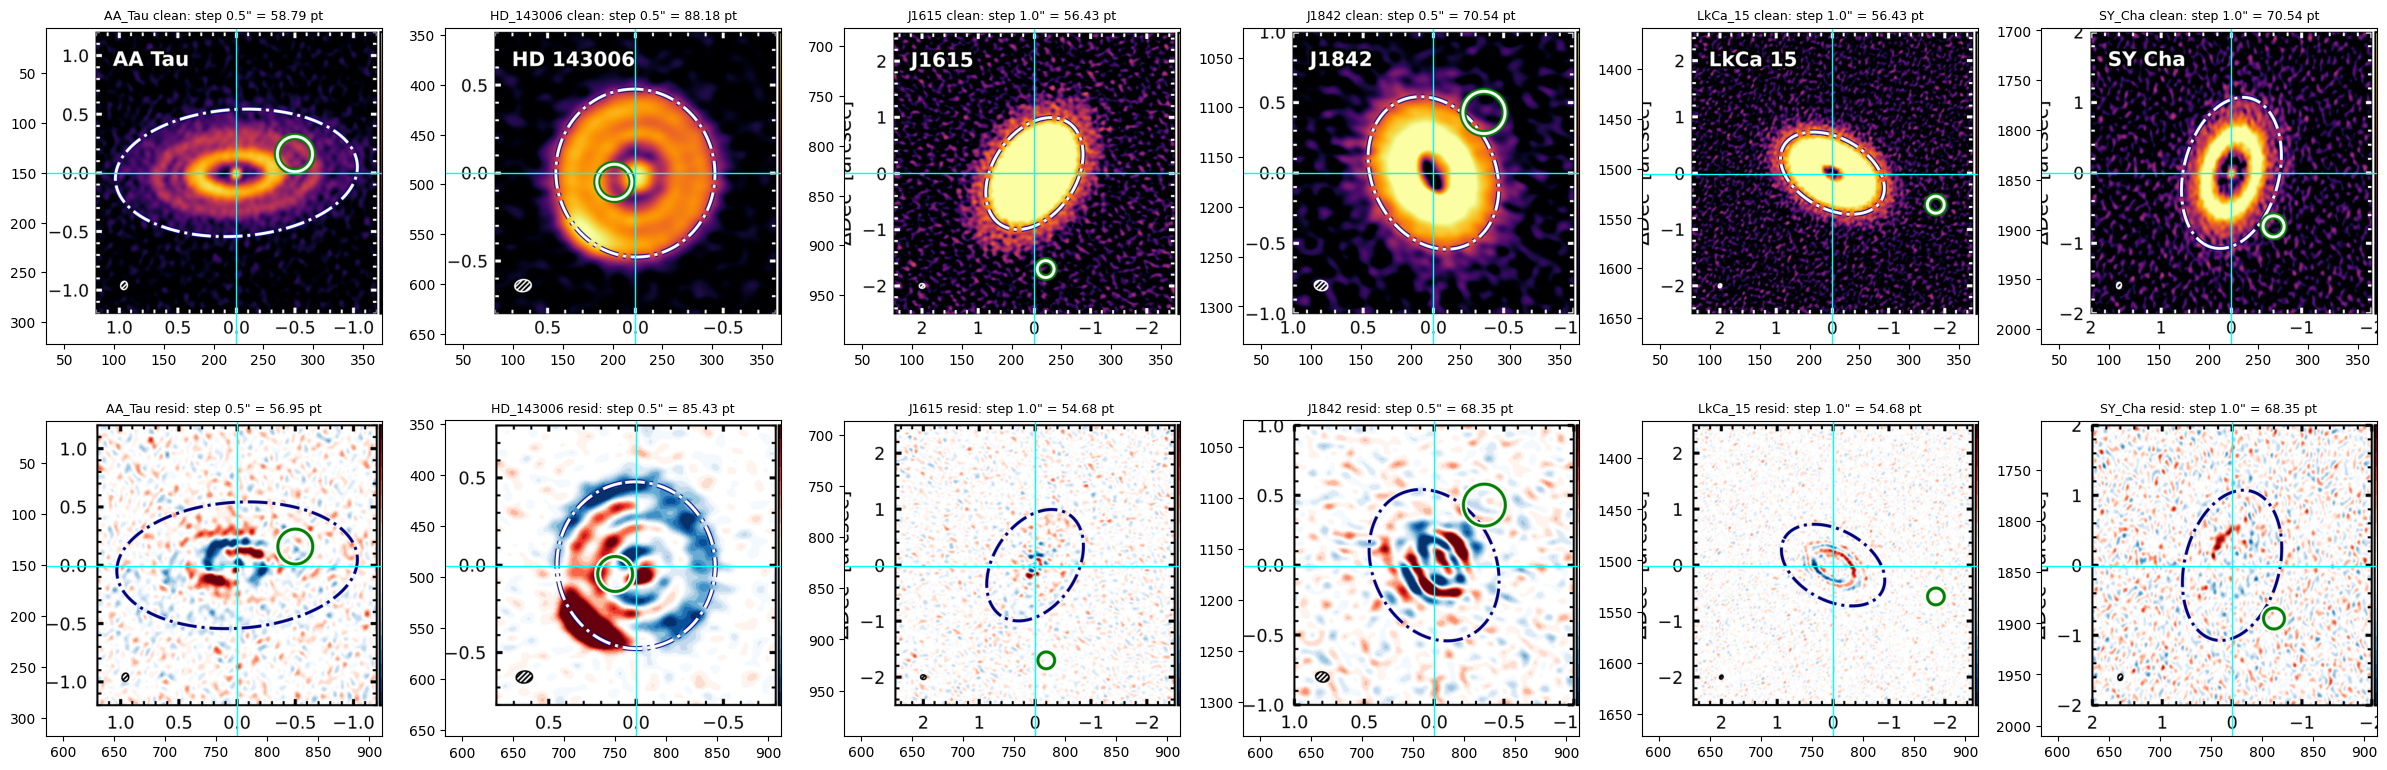

In [21]:
words = page.get_text('words')   # (x0, y0, x1, y1, text, ...)
ticks = [d['rect'] for d in dr if d['type'] == 'fs' and len(d['items']) == 1 and d['items'][0][0] == 'l'
         and abs(max(d['rect'].width, d['rect'].height) - 6) < 0.01]   # major ticks are 6 pt (minor 4 pt)

def num(t):
    try:
        return float(t)
    except ValueError:
        return None

CAL = {}
for n in names:
    for c in ['clean', 'resid']:
        r = A[n][c]
        xt = sorted(t.x0 for t in ticks if t.width == 0 and abs(t.y1 - r.y1) < 0.01 and r.x0 - 0.01 <= t.x0 <= r.x1 + 0.01)
        yt = sorted(t.y0 for t in ticks if t.height == 0 and abs(t.x0 - r.x0) < 0.01 and r.y0 - 0.01 <= t.y0 <= r.y1 + 0.01)
        xl = [w for w in words if num(w[4]) is not None and r.y1 < (w[1] + w[3]) / 2 < r.y1 + 30 and r.x0 - 30 < w[0] < r.x1]
        yl = [w for w in words if num(w[4]) is not None and r.x0 - 45 < w[0] < r.x0 and r.y0 - 20 < w[1] < r.y1]
        # minus signs are not in the text layer, so only the "0.0" label (centred on its tick) and the label step are used
        x_zero = min(xt, key=lambda t: abs(t - [(w[0] + w[2]) / 2 for w in xl if num(w[4]) == 0][0]))
        y_zero = min(yt, key=lambda t: abs(t - [(w[1] + w[3]) / 2 for w in yl if num(w[4]) == 0][0]))
        step = min(num(w[4]) for w in xl + yl if num(w[4]) > 0)
        sx, sy = step / np.median(np.diff(xt)), step / np.median(np.diff(yt))
        CAL[n, c] = dict(n_xticks=len(xt), n_yticks=len(yt), step_arcsec=step, x_zero=x_zero, y_zero=y_zero,
                         arcsec_per_pt_x=sx, arcsec_per_pt_y=sy, x_half_width_arcsec=(r.x1 - x_zero) * sx,
                         x_minus_half_width_arcsec=(x_zero - r.x0) * sx)
cal = pd.DataFrame(CAL).T
print(cal.to_string(float_format='%.5f'))
print('\nx and y scales agree to', f"{np.max(np.abs(cal.arcsec_per_pt_x / cal.arcsec_per_pt_y - 1)):.2e}")

fig, axs = plt.subplots(2, 6, figsize=(24, 8))
for i, n in enumerate(names):
    for j, c in enumerate(['clean', 'resid']):
        ax, r, k = axs[j, i], A[n][c], CAL[n, c]
        show(ax, r + (-50, -5, 5, 30), dpi=150)
        ax.axvline(k['x_zero'], color='cyan', lw=1)
        ax.axhline(k['y_zero'], color='cyan', lw=1)
        ax.set_title(f'{n} {c}: step {k["step_arcsec"]}" = {k["step_arcsec"] / k["arcsec_per_pt_x"]:.2f} pt', fontsize=9)
plt.tight_layout()
fig.savefig('companions_diag_axes_zero.png', dpi=150)
plt.show()

**STOP: check the zero lines and the axis half-widths.**

## Cell 5: find the green kink circle in each 2D panel (vector)

A candidate is a stroked path with colour (0, 0.5, 0) made of Bézier curves whose centre lies inside the panel. There must be exactly one per panel.

The circle is drawn as 16 Bézier segments. Their start points lie on the circle, evenly spaced, so their mean is the centre and their distance from it is the radius. The bounding box is not used, because it would also include the off-curve control points.

The diagnostic shows the on-curve points (yellow) and the centre (red +).

AA_Tau     clean : 1 green circle path(s), [16] bezier segments
AA_Tau     resid : 1 green circle path(s), [16] bezier segments
HD_143006  clean : 1 green circle path(s), [16] bezier segments
HD_143006  resid : 1 green circle path(s), [16] bezier segments
J1615      clean : 1 green circle path(s), [16] bezier segments
J1615      resid : 1 green circle path(s), [16] bezier segments
J1842      clean : 1 green circle path(s), [16] bezier segments
J1842      resid : 1 green circle path(s), [16] bezier segments
LkCa_15    clean : 1 green circle path(s), [16] bezier segments
LkCa_15    resid : 1 green circle path(s), [16] bezier segments
SY_Cha     clean : 1 green circle path(s), [16] bezier segments
SY_Cha     resid : 1 green circle path(s), [16] bezier segments


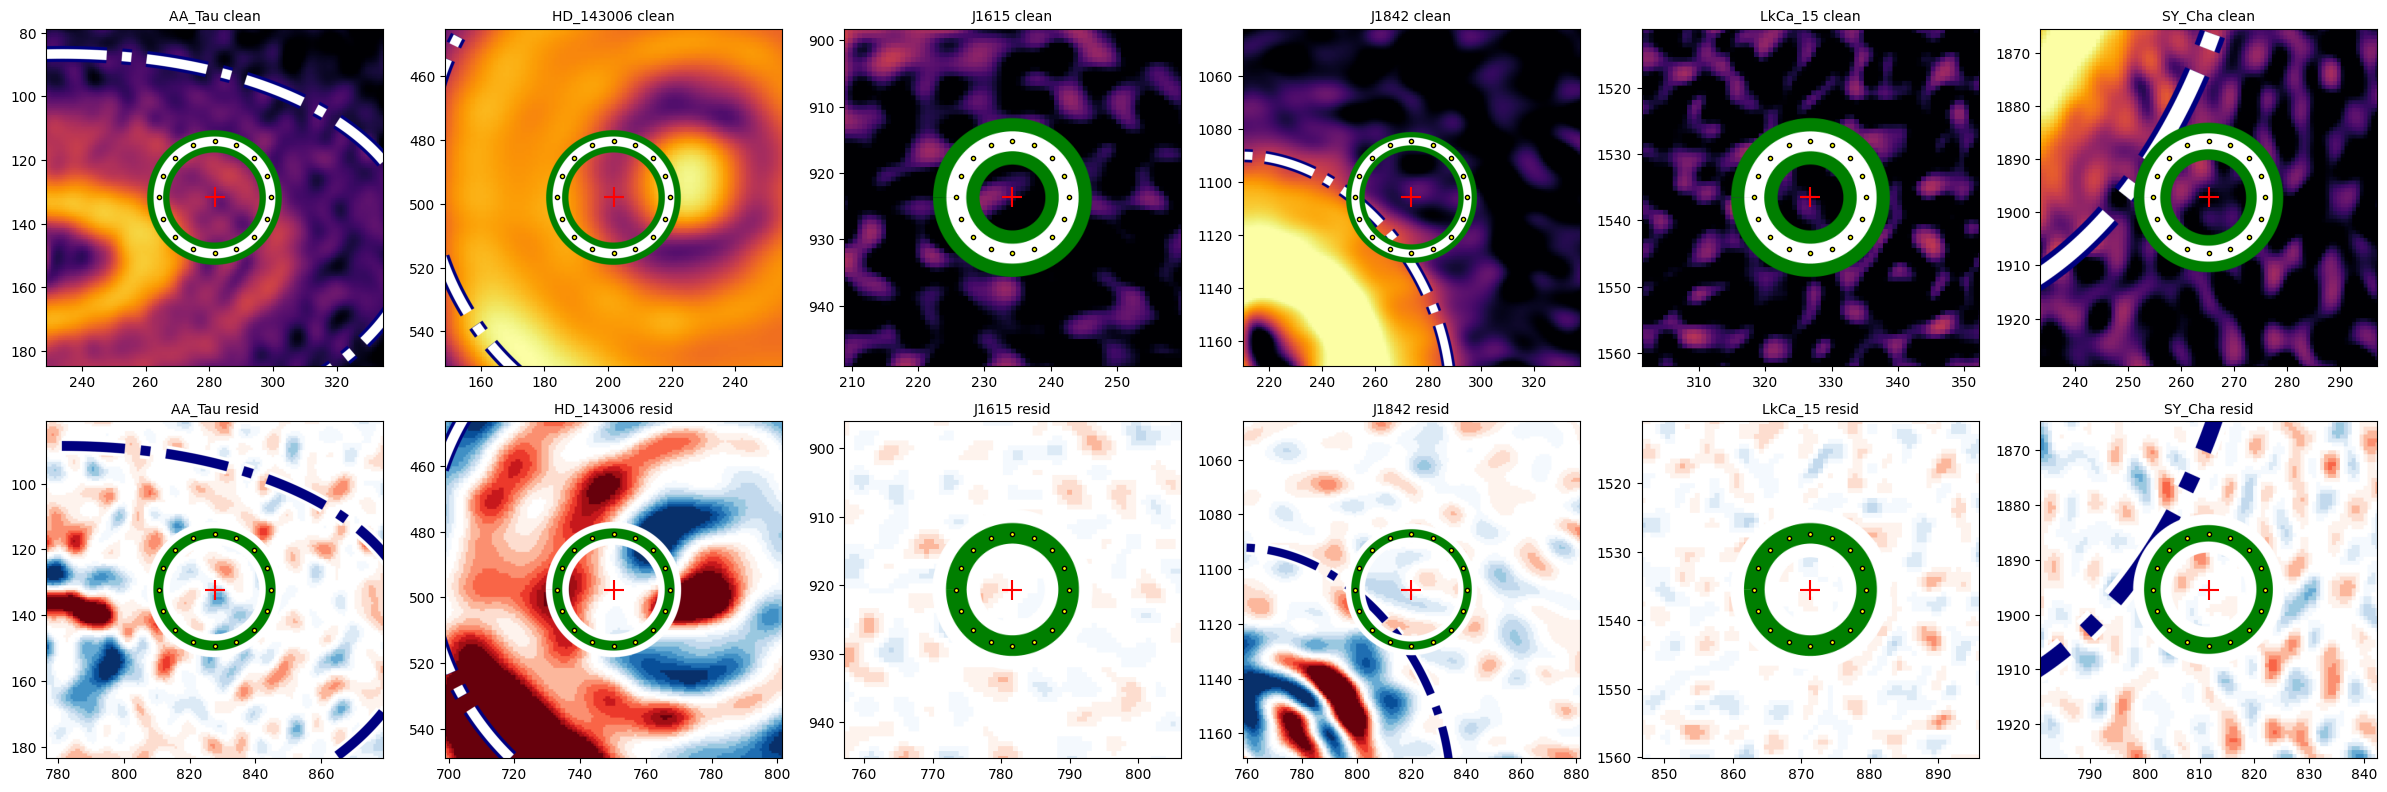

                    x_pt      y_pt  radius_pt  radius_scatter_pt  dRA_arcsec  dDec_arcsec  radius_arcsec
AA_Tau    clean 281.7108  131.7137    17.6356             0.0000     -0.5000       0.1600         0.1500
          resid 827.6436  132.2997    17.0863             0.0000     -0.5000       0.1600         0.1500
HD_143006 clean 201.7628  497.9465    17.6356             0.0000      0.1200      -0.0500         0.1000
          resid 750.1858  497.6719    17.0863             0.0000      0.1200      -0.0500         0.1000
J1615     clean 234.2123  923.6701     8.4651             0.0000     -0.2000      -1.7000         0.1500
          resid 781.6245  920.6817     8.2014             0.0000     -0.2000      -1.7000         0.1500
J1842     clean 273.7160 1105.6696    21.1627             0.0000     -0.3600       0.4300         0.1500
          resid 819.8978 1107.5592    20.5035             0.0000     -0.3600       0.4300         0.1500
LkCa_15   clean 326.7639 1536.5427     8.4651          

In [22]:
K = {}
fig, axs = plt.subplots(2, 6, figsize=(24, 8))
for i, n in enumerate(names):
    for j, c in enumerate(['clean', 'resid']):
        r, k = A[n][c], CAL[n, c]
        cand = [d for d in dr if d['type'] == 's' and d['color'] is not None and np.allclose(d['color'], GREEN, atol=0.01)
                and d['items'][0][0] == 'c' and r.contains((d['rect'].tl + d['rect'].br) / 2)]
        print(f'{n:10s} {c:6s}: {len(cand)} green circle path(s), {[len(d["items"]) for d in cand]} bezier segments')
        assert len(cand) == 1, f'AMBIGUOUS circle for {n} {c}'
        # on-curve points (segment start points) are spread evenly around the circle: their mean is the centre
        pts = np.array([[it[1].x, it[1].y] for it in cand[0]['items']])
        xc, yc = pts.mean(axis=0)
        rad = np.hypot(*(pts - [xc, yc]).T)
        K[n, c] = dict(x_pt=xc, y_pt=yc, radius_pt=rad.mean(), radius_scatter_pt=rad.std(),
                       dRA_arcsec=(k['x_zero'] - xc) * k['arcsec_per_pt_x'],
                       dDec_arcsec=(k['y_zero'] - yc) * k['arcsec_per_pt_y'],
                       radius_arcsec=rad.mean() * k['arcsec_per_pt_x'])

        ax = axs[j, i]
        win = fitz.Rect(xc - 3 * rad.mean(), yc - 3 * rad.mean(), xc + 3 * rad.mean(), yc + 3 * rad.mean()) & r
        show(ax, win, dpi=600)
        ax.plot(pts[:, 0], pts[:, 1], 'o', ms=3, mfc='yellow', mec='k')
        ax.plot(xc, yc, 'r+', ms=15, mew=1.5)
        ax.set_xlim(win.x0, win.x1); ax.set_ylim(win.y1, win.y0)
        ax.set_title(f'{n} {c}', fontsize=10)
plt.tight_layout()
fig.savefig('companions_diag_circles.png', dpi=150)
plt.show()
kin = pd.DataFrame(K).T
print(kin.to_string(float_format='%.4f'))

**STOP: check the circle detections.** The CLEAN and residual panels should give the same sky position.

## Cell 6: $R_\mathrm{cand}$ from the profile panels (vector)

- The green dotted line is a single stroked segment. It runs past its own (clipped) panel, so it is assigned by its midpoint.
- The green band is a filled rectangle.
- The radius axis is calibrated by a linear fit of the label centres to their values. These labels are all positive, so the missing minus signs do not matter here.

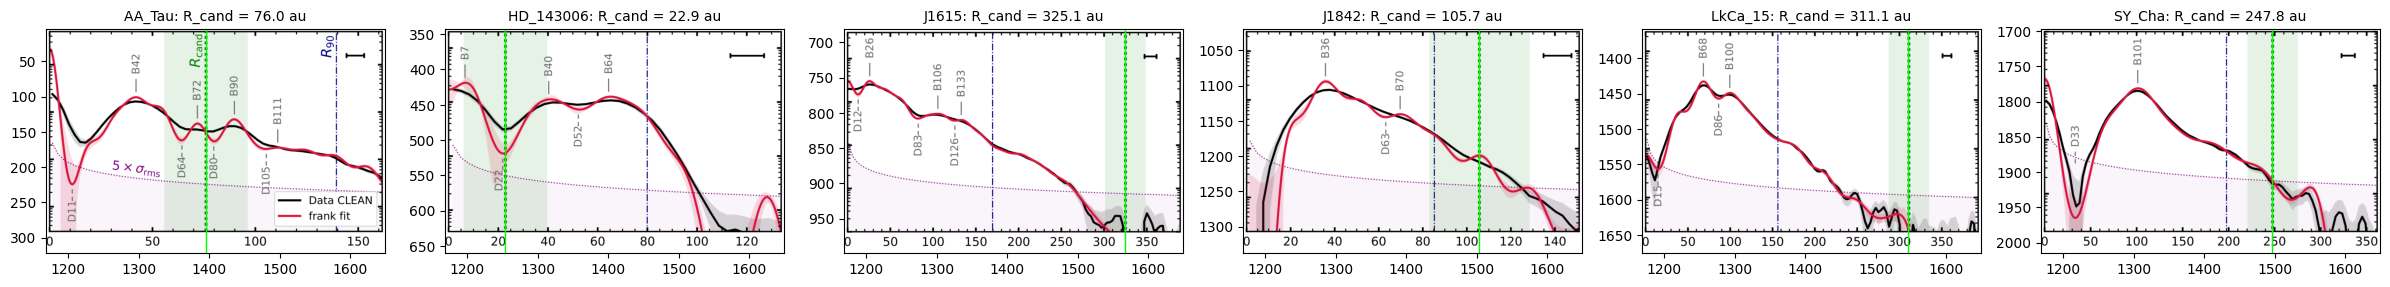

           n_labels  au_per_pt  Rcand_au  Rcand_lo_au  Rcand_hi_au
AA_Tau        4.000      0.344    76.021       55.816       96.226
HD_143006     7.000      0.285    22.880        6.150       39.610
J1615         8.000      0.828   325.083      301.743      348.423
J1842         8.000      0.321   105.710       83.060      128.360
LkCa_15       8.000      0.836   311.124      287.544      334.704
SY_Cha        8.000      0.769   247.815      220.710      274.920


In [23]:
R = {}
fig, axs = plt.subplots(1, 6, figsize=(24, 4))
for ax, n in zip(axs, names):
    r = A[n]['profile']
    line = [d for d in dr if d['type'] == 's' and d['color'] is not None and np.allclose(d['color'], GREEN, atol=0.01)
            and d['items'][0][0] == 'l' and r.contains((d['rect'].tl + d['rect'].br) / 2)]   # lines run past their (clipped) panel
    shade = [d for d in dr if d['type'] == 'fs' and d['fill'] is not None and np.allclose(d['fill'], GREEN, atol=0.01)
             and r.contains((d['rect'].tl + d['rect'].br) / 2)]
    assert len(line) == 1 and len(shade) == 1, f'AMBIGUOUS R_cand for {n}'
    xl = [w for w in words if num(w[4]) is not None and r.y1 < (w[1] + w[3]) / 2 < r.y1 + 30 and r.x0 - 20 < w[0] < r.x1]
    a, b = np.polyfit([(w[0] + w[2]) / 2 for w in xl], [num(w[4]) for w in xl], 1)   # au = a * x_pt + b
    R[n] = dict(n_labels=len(xl), au_per_pt=a, Rcand_au=a * line[0]['rect'].x0 + b,
                Rcand_lo_au=a * shade[0]['rect'].x0 + b, Rcand_hi_au=a * shade[0]['rect'].x1 + b)
    show(ax, r + (-5, -5, 5, 30), dpi=150)
    ax.axvline(line[0]['rect'].x0, color='lime', lw=1)
    ax.set_title(f'{n}: R_cand = {R[n]["Rcand_au"]:.1f} au', fontsize=10)
plt.tight_layout()
fig.savefig('companions_diag_Rcand.png', dpi=150)
plt.show()
rc = pd.DataFrame(R).T
print(rc.to_string(float_format='%.3f'))

**STOP: check the $R_\mathrm{cand}$ detections.**

## Cell 7: deproject the circle centres to the disk midplane

- Geometry: inclination and PA from the galario fit files in `D:\exoALMA_disk_data\<disk>\` (the paper's own geometry; first row = best fit).
- Distances: Table 1 of the paper.
- The same deprojection and θ convention as `verify_figure5_blue_dot.ipynb`. θ = 0 is along the major axis in the direction of PA (east of north), and θ increases toward PA − 90°.

`r_AU_over_Rcand` compares the circle's deprojected radius with the $R_\mathrm{cand}$ line drawn in the same row's profile panel. It should be ≈ 1.

In [24]:
rows = []
for n in names:
    inc, PA = np.loadtxt(rf'D:\exoALMA_disk_data\{n}\{n}_geometrical_parameters_continuum_galario.txt')[0, :2]
    for c in ['clean', 'resid']:
        X, Y = K[n, c]['dRA_arcsec'], K[n, c]['dDec_arcsec']
        PAr, incr = np.radians(PA), np.radians(inc)
        x_disk = X * np.sin(PAr) + Y * np.cos(PAr)
        y_disk = (-X * np.cos(PAr) + Y * np.sin(PAr)) / np.cos(incr)
        r_arcsec = np.hypot(x_disk, y_disk)
        rows.append(dict(disk_name=n, panel=c, dRA_arcsec=X, dDec_arcsec=Y, PA_deg=PA, inclination_deg=inc,
                         x_disk_arcsec=x_disk, y_disk_arcsec=y_disk, r_arcsec=r_arcsec, distance_pc=dist_pc[n],
                         r_AU=r_arcsec * dist_pc[n], theta_deg=np.degrees(np.arctan2(y_disk, x_disk)),
                         Rcand_profile_AU=R[n]['Rcand_au'], r_AU_over_Rcand=r_arcsec * dist_pc[n] / R[n]['Rcand_au']))
kink = pd.DataFrame(rows)
print(kink.to_string(index=False, float_format='%.4f'))

disk_name panel  dRA_arcsec  dDec_arcsec   PA_deg  inclination_deg  x_disk_arcsec  y_disk_arcsec  r_arcsec  distance_pc     r_AU  theta_deg  Rcand_profile_AU  r_AU_over_Rcand
   AA_Tau clean     -0.5000       0.1600  93.7708          58.5353        -0.5094         0.2429    0.5644          135  76.1900   154.5112           76.0210           1.0022
   AA_Tau resid     -0.5000       0.1600  93.7708          58.5353        -0.5094         0.2429    0.5644          135  76.1900   154.5112           76.0210           1.0022
HD_143006 clean      0.1200      -0.0500   7.5324          18.6939        -0.0338        -0.1325    0.1368          167  22.8392  -104.3250           22.8803           0.9982
HD_143006 resid      0.1200      -0.0500   7.5324          18.6939        -0.0338        -0.1325    0.1368          167  22.8392  -104.3250           22.8803           0.9982
    J1615 clean     -0.2000      -1.7000 146.1433          47.0978         1.3003        -1.6352    2.0892          156 325.9

## Cell 8: save the raw result (the file is never overwritten)

In [25]:
fn, i = 'companions_kink_raw.txt', 1
while os.path.exists(fn):   # never overwrite an earlier result: use the next free _vN name
    i += 1
    fn = f'companions_kink_raw_v{i}.txt'
with open(fn, 'x') as f:
    f.write(kink.to_string(index=False, float_format='%.6f') + '\n')
print(fn)
print(open(fn).read())

companions_kink_raw_v3.txt
disk_name panel  dRA_arcsec  dDec_arcsec     PA_deg  inclination_deg  x_disk_arcsec  y_disk_arcsec  r_arcsec  distance_pc       r_AU   theta_deg  Rcand_profile_AU  r_AU_over_Rcand
   AA_Tau clean   -0.500000     0.160000  93.770798        58.535312      -0.509440       0.242868  0.564370          135  76.189995  154.511210         76.020959         1.002224
   AA_Tau resid   -0.500000     0.160000  93.770798        58.535312      -0.509440       0.242868  0.564371          135  76.190018  154.511177         76.020959         1.002224
HD_143006 clean    0.120000    -0.050000   7.532368        18.693917      -0.033838      -0.132509  0.136762          167  22.839201 -104.325026         22.880341         0.998202
HD_143006 resid    0.120000    -0.050000   7.532368        18.693917      -0.033838      -0.132509  0.136762          167  22.839187 -104.325028         22.880341         0.998201
    J1615 clean   -0.200000    -1.699999 146.143279        47.097757     

## Cell 9: compare with Pinte et al. 2025

- `r_AU_Table2`: radius of the model planet in the phantom + mcfost table (Table 2) of Pinte et al. 2025. This is where the planet was put to reproduce the kink, not the measured kink position.
- `r_AU_fig5_vector`, `theta_deg_fig5`: the Figure 5 dot of Pinte et al. 2025 with the vector-endpoint scale-bar calibration (`figure5_blue_dot_raw_v9.txt`), deprojected here with the same geometry and distances as Cell 7.
- HD 143006 has no Table 2 model and no Figure 5 dot (NaN).

In [26]:
# Pinte et al. 2025 Table 2: r_planet (au) of the phantom + mcfost model planet (no HD 143006 model there)
r_planet_table2 = {'AA_Tau': 80, 'J1615': 310, 'J1842': 105, 'LkCa_15': 240, 'SY_Cha': 140}

# Figure 5 dot of Pinte et al. 2025, vector-endpoint calibration (verify_figure5_blue_dot.ipynb Cell 11),
# deprojected with the same geometry and distances as Cell 7 (x_image is to the right = west, so dRA = -x_image)
f5 = pd.read_csv('figure5_blue_dot_raw_v9.txt', sep=r'\s+')
f5['disk_name'] = f5.disk_name.map({'LkCa15': 'LkCa_15', 'SYCha': 'SY_Cha', 'AATau': 'AA_Tau', 'J1615': 'J1615', 'J1842': 'J1842'})
r5, t5 = {}, {}
for _, m in f5.iterrows():
    n = m.disk_name
    inc, PA = np.radians(np.loadtxt(rf'D:\exoALMA_disk_data\{n}\{n}_geometrical_parameters_continuum_galario.txt')[0, :2])
    X, Y = -m.x_image_arcsec, m.y_image_arcsec
    x_disk = X * np.sin(PA) + Y * np.cos(PA)
    y_disk = (-X * np.cos(PA) + Y * np.sin(PA)) / np.cos(inc)
    r5[n], t5[n] = np.hypot(x_disk, y_disk) * dist_pc[n], np.degrees(np.arctan2(y_disk, x_disk))

cmp = pd.DataFrame({'r_AU_this_fig': kink[kink.panel == 'clean'].set_index('disk_name').r_AU,
                    'r_AU_Table2': pd.Series(r_planet_table2),
                    'r_AU_fig5_vector': pd.Series(r5),
                    'theta_deg_this_fig': kink[kink.panel == 'clean'].set_index('disk_name').theta_deg,
                    'theta_deg_fig5': pd.Series(t5)})
print(cmp.to_string(float_format='%.1f'))

           r_AU_this_fig  r_AU_Table2  r_AU_fig5_vector  theta_deg_this_fig  theta_deg_fig5
AA_Tau              76.2         80.0              83.5               154.5           127.6
HD_143006           22.8          NaN               NaN              -104.3             NaN
J1615              325.9        310.0             293.3               -51.5           -50.0
J1842              105.7        105.0             106.8                71.2            63.6
LkCa_15            308.7        240.0             308.7               162.2           162.2
SY_Cha             249.6        140.0             219.7               -64.6           -78.2


so SYCha, and lkca15 is different
